In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [3]:
DATA_DIR    = Path("../../data/splits")
RESULTS_DIR = Path("../../results")
MODEL_DIR   = RESULTS_DIR / "models/finetuned_distilbert"
BATCH_SIZE  = 32
MAX_LENGTH  = 64

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Устройство: {device}")

Устройство: mps


In [4]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_DIR)
model     = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [5]:
test_df = pd.read_csv(DATA_DIR / "test.csv")
print(f"Тестовых примеров: {len(test_df)}")

class CLINCDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.texts = df["text"].tolist()
        self.labels = df["intent"].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

test_dataset = CLINCDataset(test_df, tokenizer)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Батчей в тесте: {len(test_loader)}")

Тестовых примеров: 3578
Батчей в тесте: 112


In [6]:
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Предсказано примеров: {len(all_preds)}")

Предсказано примеров: 3578


In [9]:
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Macro F1: {macro_f1:.4f}")

metrics = {
    "experiment": "exp01_finetuning",
    "model": "distilbert-base-uncased",
    "accuracy": round(accuracy, 4),
    "macro_f1": round(macro_f1, 4),
    "test_samples": len(test_df),
    "num_classes": test_df["intent"].nunique(),
}

pd.DataFrame([metrics]).to_csv(RESULTS_DIR / "metrics/exp01_metrics.csv", index=False)

Accuracy: 0.9424 (94.24%)
Macro F1: 0.9465


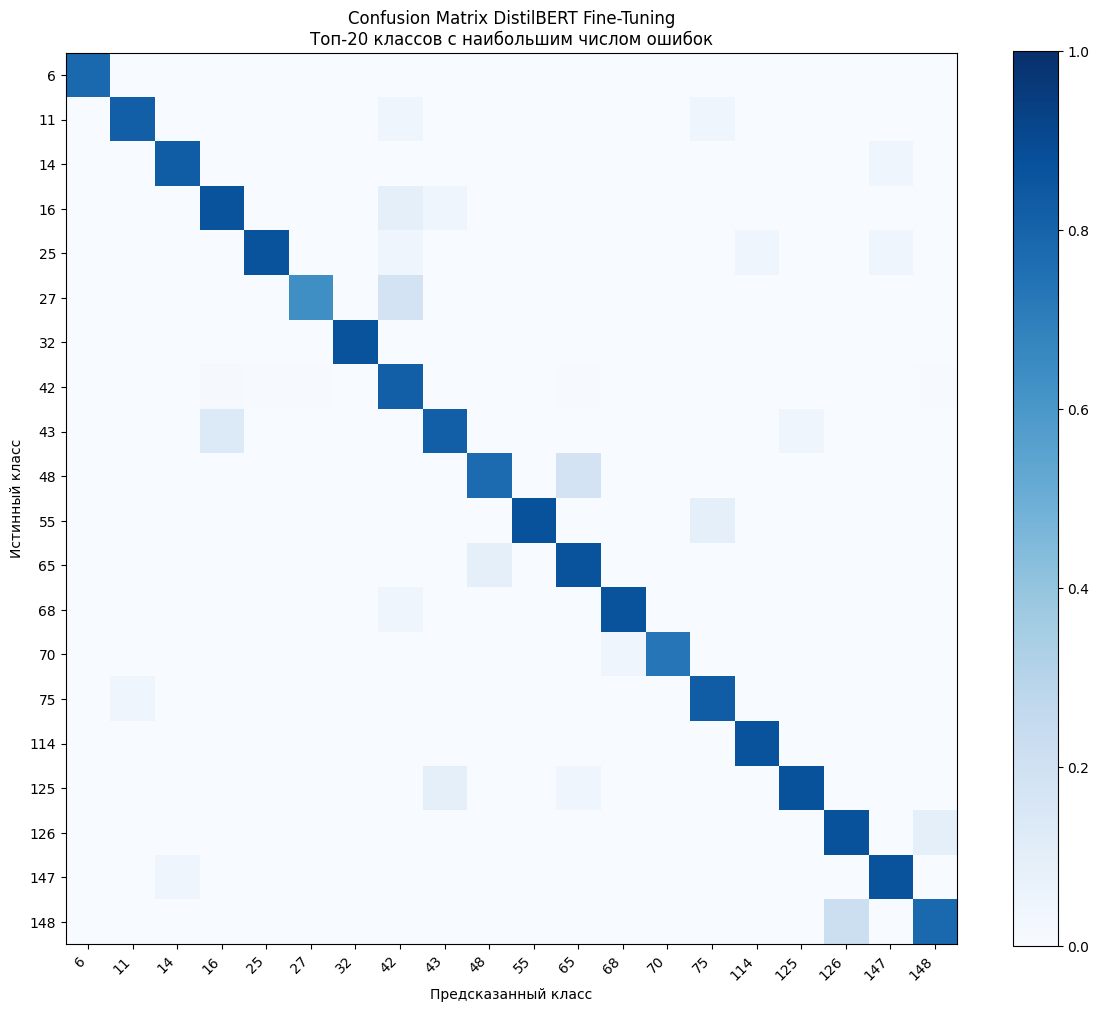

In [10]:
cm = confusion_matrix(all_labels, all_preds)

cm_normalized = cm.astype(float)
cm_normalized /= cm.sum(axis=1, keepdims=True)

errors_per_class = cm.sum(axis=1) - np.diag(cm)
top_indices = np.argsort(errors_per_class)[::-1][:20]
top_indices = sorted(top_indices)

cm_top = cm_normalized[np.ix_(top_indices, top_indices)]
top_labels = [str(i) for i in top_indices]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_top, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(top_labels)))
ax.set_yticks(range(len(top_labels)))
ax.set_xticklabels(top_labels, rotation=45, ha="right")
ax.set_yticklabels(top_labels)
ax.set_xlabel("Предсказанный класс")
ax.set_ylabel("Истинный класс")
ax.set_title("Confusion Matrix DistilBERT Fine-Tuning\nТоп-20 классов с наибольшим числом ошибок")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "plots/exp01_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

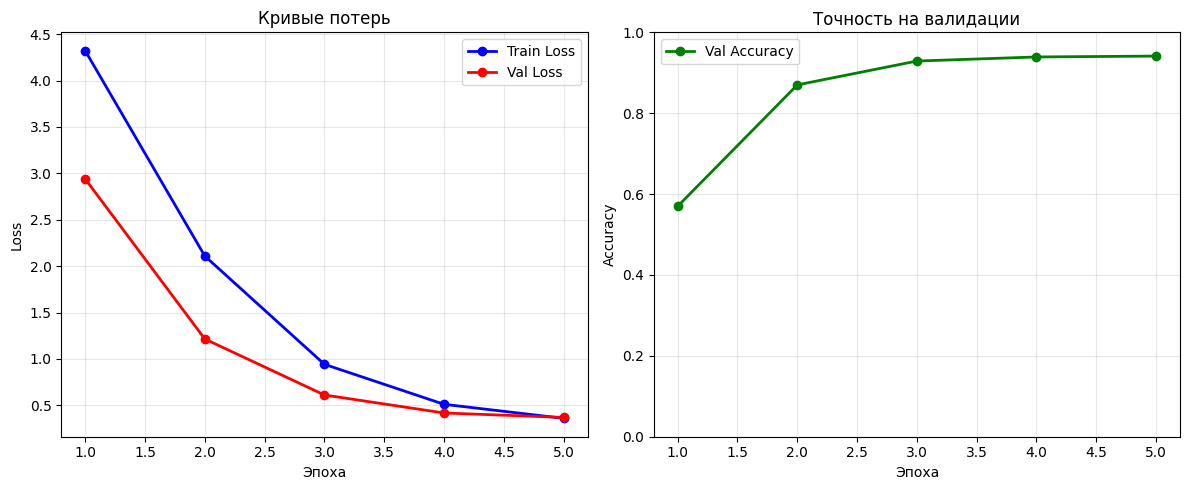

In [14]:
import json

with open(RESULTS_DIR / "logs/exp01_training_log.json") as f:
    training_history = json.load(f)

epochs     = [e["epoch"] for e in training_history]
train_loss = [e["train_loss"] for e in training_history]
val_loss   = [e["val_loss"] for e in training_history]
val_acc    = [e["val_acc"] for e in training_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(epochs, train_loss, "b-o", label="Train Loss", linewidth=2)
ax1.plot(epochs, val_loss, "r-o", label="Val Loss",   linewidth=2)
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("Loss")
ax1.set_title("Кривые потерь")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_acc, "g-o", label="Val Accuracy", linewidth=2)
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("Accuracy")
ax2.set_title("Точность на валидации")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "plots/exp01_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()